# Nanophotonic Realization — Mode Overlap and Effective Couplings

Builds a dimerized resonator chain, extracts SSH coupling strengths via normalized
mode overlap integrals, and verifies the topological condition $t_2 > t_1$.


In [1]:
import sys
sys.path.insert(0, "..")   # find src/nh_topo from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo.config import load_all, get_physics_params, get_figure_dir
from pathlib import Path

cfg = load_all(config_dir="../config")
p   = get_physics_params(cfg)

# Quick confirmation
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}")
print(f"Topological: t2/t1 = {p['t2']/p['t1']:.2f} > 1 → |nu|={nt.topological_invariant(p['t1'], p['t2'])}")


t1=0.8, t2=1.2, gamma=0.3, N=20
Topological: t2/t1 = 1.50 > 1 → |nu|=1


In [2]:
a       = p['a']
d_intra = p['d_intra'] * a
d_inter = p['d_inter'] * a
width   = 0.45 * a

print(f"d_intra = {d_intra:.3f} a  (larger gap → weaker t1)")
print(f"d_inter = {d_inter:.3f} a  (smaller gap → stronger t2)")
print(f"Topological condition: d_inter < d_intra → {d_inter < d_intra}")

centers, modes, x = nt.build_resonator_chain(
    p['N'], a, d_intra, d_inter, width)
cdata = nt.extract_ssh_couplings(p['N'], modes, x)

print(f"\nt1_eff = {cdata['t1_mean']:.5f}")
print(f"t2_eff = {cdata['t2_mean']:.5f}")
print(f"Ratio  = {cdata['ratio']:.4f}  (topological: {cdata['ratio'] > 1})")
assert cdata['ratio'] > 1.0, f"Expected t2>t1, got ratio={cdata['ratio']:.3f}"


d_intra = 0.600 a  (larger gap → weaker t1)
d_inter = 0.400 a  (smaller gap → stronger t2)
Topological condition: d_inter < d_intra → True

t1_eff = 0.64118
t2_eff = 0.82075
Ratio  = 1.2801  (topological: True)


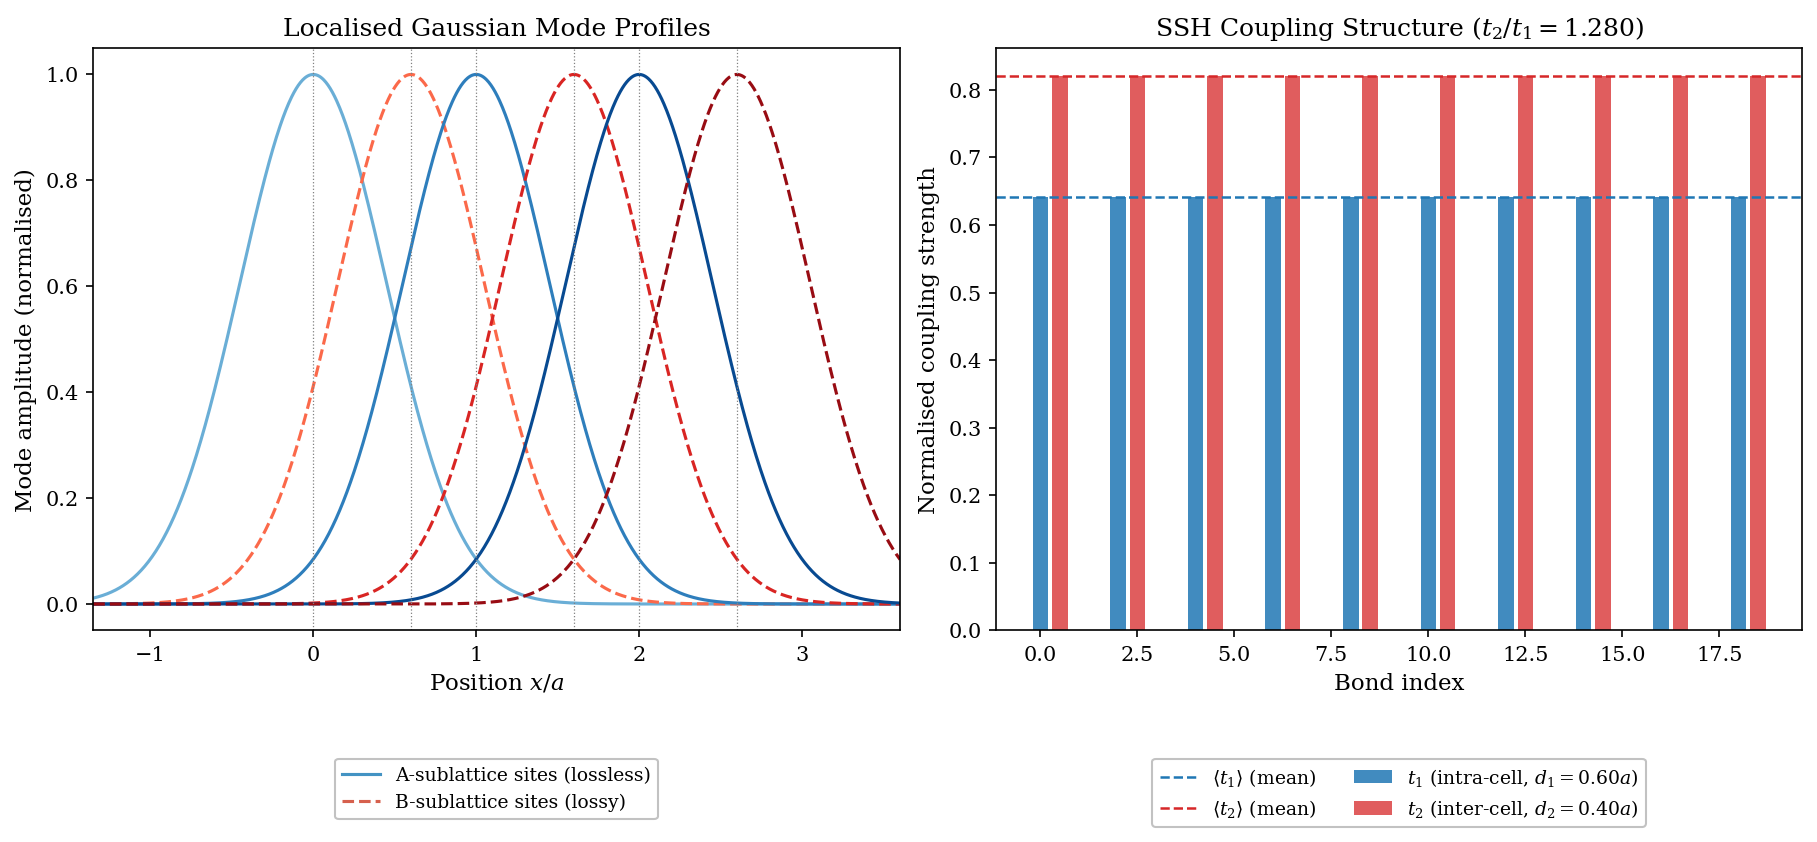

In [3]:
fig, axes = nt.plotting.plot_coupling_extraction(
    x, a, centers, modes, cdata, d_intra, d_inter)
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '04_effective_mode_nanophotonics'), "01_coupling_extraction")
plt.show()
